In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import glob
import ast
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
#X1Z, X2Z, X1W
path = "/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker5*.log"
log_file = glob.glob(path)
log_file.remove("/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker5.log")
log_file.append("/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker60.log")
log_file = sorted(log_file)
log_file

['/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker51.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker52.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker53.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker54.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker55.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker56.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker57.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker58.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker59.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_run_ewkinos/logs/walker60.log']

In [2]:
#X1Z, X2Z, X3Z
num = np.arange(1, 11)
path = "/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker5*.log"
log_file = [f"/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker{i}.log" for i in num]
log_file

['/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker1.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker2.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker3.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker4.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker5.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker6.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker7.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker8.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker9.log',
 '/scratch-cbe/users/sahana.narasimha/mcmc_2/logs/walker10.log']

In [3]:
def read_log_file(file_path):
    
    step_list,muhat_list,proto_list,accratio_list = [],[],[],[]

    step_pattern = re.compile(r'\[randomWalker.*\] Step (\d+) begins')
    muhat_pattern = re.compile(r'with muhat ([\d.]+)')
    proto_pattern = re.compile(r"Protomodel: ({.*})")
    accratio_pattern = re.compile(r"Acceptance ratio (\d+(\.\d+)?)")

    none_pattern = re.compile(r'K is none, return to previous model') #need this when the second set of runs do not print the protomodel

    current_step = None
    current_muhat = np.nan
    current_proto = {}
    current_accratio = 0.0
    ctr = 0
    with open(file_path, 'r') as file:
        for line in file:
            step_match = step_pattern.search(line)
            if step_match:
                if current_step:
                    step_list.append(current_step)
                    muhat_list.append(current_muhat)
                    proto_list.append(current_proto)
                    accratio_list.append(current_accratio)
                
                current_step = int(step_match.group(1))
                #if current_step > 1400: print(current_step)
                current_muhat = np.nan
                current_proto = {}
                current_accratio = 0.0

            none_match = none_pattern.search(line)
            muhat_match = muhat_pattern.search(line)
            proto_match = proto_pattern.search(line)
            accratio_match = accratio_pattern.search(line)
            ctr = 0
            if muhat_match:
                ctr += 1
                try:
                    current_muhat = float(muhat_match.group(1))
                except ValueError:
                    current_muhat = np.nan

            if proto_match:
                ctr += 1
                current_proto = eval(proto_match.group(1))

            if accratio_match:
                ctr += 1
                current_accratio = float(accratio_match.group(1))
                            
            if none_match:
                if ctr != 3:            #if the protomodel is not printed because muhat did not converge to 1 in the second set of runs
                    current_muhat = None
                    current_proto = {}
                    current_accratio = None
            
        if current_step:
            step_list.append(current_step)
            muhat_list.append(current_muhat)
            proto_list.append(current_proto)
            accratio_list.append(current_accratio)
    
    return step_list, muhat_list, proto_list, accratio_list

In [4]:
def get_proto_par(proto):
    
    accepted = proto['Accepted']
    K = proto['K']
    TL = proto['TL']
    return accepted, K, TL

def get_all_proto(step_list, proto_list):
    acc_list, K_list, TL_list,steps = [],[],[],[]
    for i,proto in enumerate(proto_list):
        if proto == {}:         #if the protomodel is not printed because muhat did not converge to 1
            steps.append(step_list[i])
            K_list.append(None)
            TL_list.append(None)
            acc_list.append(2)
            continue
        acc, K, TL = get_proto_par(proto)
        acc_list.append(acc)
        K_list.append(K)
        TL_list.append(TL)
    print(steps)
    K_list,TL_list = plot_trace_K(step_list, acc_list, K_list, TL_list)
    return K_list, TL_list

In [5]:
def plot_trace_K(step_list, accepted, K, TL):
    K_list,TL_list = [],[]
    #step_list  = step_list[:-1]
    ind_acc = 0
    
    for i,acc in enumerate(accepted):
        if acc == 0:
            ind_acc = i
            if K[i] is not None:
                K_list.append(K[i])
                TL_list.append(TL[i])
                #if i%1000==0: print(f"{i}, Step: {step_list[i]}, accepted: Current K {K[i]}, accepting K {K[ind_acc]}")
                #print(f"{i}, {ind_acc}, ki {K[i]}, kacc {K[ind_acc]}, {K[i]==K[ind_acc]}")
            else: 
                if ind_acc == 0: 
                    K_list.append(None)
                    TL_list.append(None)
                    continue
                ind_acc = i-1
                K_list.append(K[i-1])
                TL_list.append(TL[i-1])
        else:
            if K[ind_acc] is not None: 
                K_list.append(K[ind_acc])
                TL_list.append(TL[ind_acc])
                #if i%1000==0: print(f"{i}, Step: {step_list[i]}, Not accepted: Current K {K[i]}, accepting K {K[ind_acc]}")
                #print(f"{i}, {ind_acc}, ki {K[i]}, kacc {K[ind_acc]}, {K[i]==K[ind_acc]}")
            else:
                if ind_acc == 0: 
                    K_list.append(None)
                    TL_list.append(None)
                    continue
                K_list.append(K[i-1])
                TL_list.append(TL[i-1]) 
                print(f"{i}, error, Step : {step_list[i]}, K: {K[i]}, TL: {TL[i]}, accepted K: {K_list[i]}")
        #if i in range(4141, 4151):
        #    print(f"{i}, Step : {step_list[i]}, K: {K[i]}, TL: {TL[i]}, accepted K: {K_list[i]}")
    if len(step_list) != len(K_list):
        if len(step_list) < len(K_list): step_list.append(step_list[-1]+1)
        else: step_list = step_list[:-1]
    
    #print(K_list[6607:6615])
    #print(TL_list[6607:6615])
    # Create a figure with two subplots
    
    #fig = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=["K vs Step", "TL vs Step"])
    fig = make_subplots(rows=1, cols=1, shared_xaxes=True, subplot_titles=["nll vs Step"])
    # First subplot (K)
    #fig.add_trace(go.Scatter(x=step_list, y=K_list, mode='lines', name='-2logL1 + prior'), row=1, col=1)

    # Second subplot (TL)
    fig.add_trace(go.Scatter(x=step_list, y=TL_list, mode='lines', name='-2logL1'), row=1, col=1)
    
    # Update layout
    fig.update_layout(height=500, width=800, title_text="nll vs Step", showlegend=False)
    fig.update_xaxes(title_text="Step", row=1, col=1)
    #fig.update_yaxes(title_text="-2logL1 + prior", row=1, col=1)
    fig.update_yaxes(title_text="-2logL1", row=1, col=1)

    import plotly.io as pio
    pio.renderers.default = "vscode"  # or "jupyterlab"
    #import plotly.io as pio
    pio.show(fig)
    
    return K_list, TL_list

def plot_num_of_par(step_list, proto_list, K_list):
    step_list = step_list[:-1]
    num_list = []
    ind_acc = 0
    for i,proto in enumerate(proto_list):
        if proto == {}: continue
        acc = proto['Accepted']
        num_par = len(proto['masses'].keys())
        K = proto['K']
        if acc == 0:   
            num_list.append(num_par)
            ind_acc =i
        else:
            proto_prev = proto_list[ind_acc]
            num_par = len(proto_prev['masses'].keys())
            num_list.append(num_par)
    
    fig = go.Figure()

    # First y-axis (Num)
    fig.add_trace(go.Scatter(x=step_list, y=num_list, mode='lines', name='Num', 
                            line=dict(color='blue', width=2), opacity=0.6, yaxis='y1'))

    # Second y-axis (K)
    fig.add_trace(go.Scatter(x=step_list, y=K_list, mode='lines', name='K', 
                            line=dict(color='red', width=2), opacity=0.4, yaxis='y2'))

    # Update layout for dual axes
    fig.update_layout(title="Num and K vs Step",
        xaxis=dict(title="Step"),
        yaxis=dict(title=dict(text="Num", font=dict(color="blue")), tickfont=dict(color="blue")),
        yaxis2=dict(title=dict(text="K", font=dict(color="red")), tickfont=dict(color="red"),
                    overlaying='y', side='right'),
        legend=dict(x=0.7, y=1.1),
        width=800, height=500
    )
    
    import plotly.io as pio
    pio.renderers.default = "vscode"  # or "jupyterlab"
    #import plotly.io as pio
    pio.show(fig)


In [6]:
K_lists,TL_lists = [],[]
step_lists = []
proto_lists = []
for i,file in enumerate(log_file):
    #if i==9:
    filename = file.split('/')[-1]
    print(f"{filename}")
    step_list, muhat_list, proto_list,accratio_list = read_log_file(file)
    print(len(step_list))
    K_list,TL_list = get_all_proto(step_list, proto_list)
    K_lists.append(K_list)
    TL_lists.append(TL_list)
    step_lists.append(step_list)
    proto_lists.append(proto_list)

walker1.log
13824
[1, 2, 5, 6, 7, 9, 10, 11, 12, 14, 16, 19, 22, 25, 30, 31, 36, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 62, 64, 74, 79, 88, 90, 91, 92, 102, 112, 113, 116, 120, 135, 139, 143, 144, 145, 146, 150, 151, 154, 155, 159, 161, 164, 167, 172, 178, 186, 189, 192, 199, 201, 202, 203, 204, 207, 215, 225, 237, 238, 241, 243, 245, 248, 251, 261, 269, 272, 279, 291, 292, 295, 296, 303, 309, 312, 315, 318, 343, 345, 352, 354, 364, 371, 379, 392, 398, 406, 407, 412, 419, 439, 444, 451, 454, 465, 472, 489, 491, 494, 501, 506, 509, 511, 519, 522, 529, 532, 534, 541, 545, 548, 551, 562, 567, 569, 575, 576, 578, 583, 585, 594, 598, 604, 612, 615, 618, 619, 625, 637, 639, 646, 649, 650, 660, 663, 665, 672, 674, 675, 688, 698, 699, 700, 703, 715, 723, 725, 732, 733, 738, 739, 740, 743, 747, 751, 753, 756, 764, 767, 772, 776, 781, 782, 783, 785, 786, 792, 794, 802, 804, 805, 809, 815, 820, 821, 825, 831, 834, 837, 838, 848, 864, 866, 868, 875, 881, 882, 885, 898, 899, 907, 908, 

walker2.log
118
[7, 10, 11, 12, 14, 19, 22, 23, 25, 28, 34, 36, 37, 38, 39, 40, 43, 44, 45, 50, 52, 53, 55, 56, 60, 62, 65, 69, 71, 77, 80, 82, 87, 92, 94, 96, 97, 102, 106, 107, 118]


walker3.log
29232
[2, 9, 13, 19, 22, 26, 27, 44, 49, 53, 55, 57, 61, 65, 86, 90, 97, 100, 101, 106, 115, 117, 125, 129, 133, 143, 155, 159, 166, 169, 171, 173, 174, 176, 177, 180, 184, 193, 204, 205, 216, 217, 224, 237, 238, 239, 243, 251, 252, 253, 254, 258, 261, 266, 268, 269, 275, 288, 294, 300, 305, 314, 316, 318, 324, 325, 330, 334, 353, 354, 356, 365, 369, 379, 387, 396, 401, 405, 408, 419, 420, 422, 426, 431, 435, 438, 449, 450, 452, 455, 456, 467, 469, 470, 471, 473, 474, 477, 484, 487, 489, 495, 497, 505, 507, 508, 515, 523, 538, 540, 546, 547, 553, 556, 563, 567, 575, 579, 585, 592, 593, 606, 615, 622, 627, 636, 640, 643, 645, 647, 655, 657, 662, 668, 678, 682, 684, 686, 687, 688, 697, 703, 704, 709, 711, 720, 723, 724, 738, 752, 753, 754, 769, 773, 776, 781, 791, 793, 794, 797, 802, 808, 821, 834, 838, 839, 842, 851, 862, 866, 868, 872, 873, 886, 894, 907, 909, 910, 913, 915, 921, 934, 935, 941, 942, 947, 948, 952, 954, 959, 962, 982, 994, 1003, 1006, 1007, 1011, 1013, 1016,

walker4.log
514
[4, 6, 7, 10, 12, 17, 22, 24, 25, 29, 31, 38, 43, 46, 47, 55, 61, 67, 68, 69, 74, 76, 80, 82, 85, 87, 92, 99, 111, 117, 118, 123, 128, 132, 133, 137, 141, 143, 149, 150, 158, 163, 164, 172, 181, 182, 184, 187, 190, 192, 194, 195, 198, 204, 205, 216, 219, 223, 230, 232, 233, 238, 247, 254, 256, 258, 259, 266, 270, 276, 277, 278, 280, 284, 288, 289, 292, 294, 295, 296, 303, 304, 307, 309, 312, 315, 316, 328, 335, 337, 339, 342, 344, 345, 348, 353, 354, 355, 357, 363, 364, 371, 373, 375, 381, 382, 383, 386, 394, 397, 399, 400, 401, 404, 407, 408, 416, 417, 418, 422, 429, 430, 431, 437, 443, 449, 452, 453, 454, 457, 461, 464, 465, 467, 470, 476, 477, 483, 486, 488, 491, 492, 495, 501, 502, 503, 504, 507, 508, 510, 513, 514]


walker5.log
13260
[1, 2, 5, 7, 14, 16, 17, 22, 23, 25, 28, 30, 31, 32, 34, 38, 40, 42, 43, 44, 46, 47, 50, 52, 53, 54, 55, 57, 58, 59, 60, 65, 69, 70, 72, 82, 83, 89, 96, 105, 107, 124, 127, 128, 133, 136, 141, 142, 145, 146, 149, 152, 162, 163, 164, 173, 176, 179, 180, 185, 186, 187, 193, 203, 220, 226, 238, 243, 250, 258, 262, 263, 264, 265, 271, 273, 277, 280, 287, 288, 296, 298, 304, 317, 321, 339, 343, 344, 351, 376, 380, 387, 389, 390, 394, 402, 423, 460, 464, 466, 470, 472, 475, 477, 484, 486, 491, 497, 500, 506, 509, 516, 526, 536, 538, 539, 543, 544, 545, 546, 553, 554, 555, 558, 561, 564, 569, 570, 575, 580, 581, 583, 586, 588, 592, 613, 622, 625, 631, 636, 642, 644, 645, 646, 655, 667, 668, 670, 675, 678, 680, 689, 698, 703, 707, 708, 714, 720, 723, 728, 736, 737, 746, 749, 750, 751, 757, 758, 765, 767, 771, 779, 781, 787, 794, 797, 809, 810, 813, 815, 817, 826, 827, 829, 831, 840, 843, 845, 851, 852, 853, 854, 863, 869, 870, 905, 918, 919, 921, 928, 937, 938, 944, 964, 965,

walker6.log
106
[2, 4, 8, 9, 14, 20, 23, 24, 26, 27, 32, 38, 39, 51, 53, 54, 59, 67, 74, 76, 79, 87, 88, 89, 92, 94, 95, 96, 97, 99, 101, 103, 106]


walker7.log
480
[2, 7, 9, 10, 12, 14, 17, 19, 20, 21, 31, 35, 42, 46, 55, 58, 59, 63, 64, 70, 72, 77, 78, 80, 84, 88, 89, 94, 96, 105, 108, 109, 111, 112, 117, 118, 125, 126, 129, 131, 134, 142, 146, 147, 148, 149, 152, 156, 160, 165, 169, 170, 171, 172, 173, 175, 181, 182, 183, 184, 186, 190, 191, 198, 201, 203, 204, 213, 217, 220, 222, 225, 227, 229, 233, 241, 242, 245, 248, 250, 251, 257, 258, 264, 265, 266, 269, 271, 276, 279, 282, 283, 285, 293, 295, 298, 301, 305, 306, 310, 311, 319, 325, 329, 332, 333, 334, 335, 338, 342, 345, 346, 347, 349, 350, 353, 360, 361, 365, 366, 370, 372, 373, 381, 385, 388, 393, 394, 395, 396, 397, 400, 404, 412, 413, 417, 420, 422, 424, 427, 428, 431, 437, 439, 441, 446, 449, 450, 453, 456, 463, 470, 472, 476, 480]


walker8.log
297
[1, 9, 11, 12, 15, 20, 21, 22, 23, 24, 28, 29, 30, 31, 35, 36, 37, 40, 41, 43, 46, 48, 49, 51, 53, 55, 57, 59, 62, 63, 64, 72, 73, 84, 89, 90, 92, 95, 100, 108, 111, 118, 121, 123, 125, 126, 130, 131, 132, 135, 137, 138, 148, 158, 161, 163, 164, 167, 170, 171, 172, 174, 175, 181, 184, 185, 187, 188, 189, 195, 203, 206, 208, 209, 210, 213, 216, 217, 218, 225, 227, 229, 231, 234, 242, 245, 246, 256, 257, 258, 267, 268, 269, 272, 273, 274, 275, 278, 280, 283, 285, 290, 291, 293, 295, 297]


walker9.log
249
[2, 3, 9, 12, 19, 20, 22, 23, 25, 27, 29, 30, 31, 32, 40, 43, 44, 46, 47, 49, 51, 59, 66, 72, 74, 77, 81, 82, 92, 95, 100, 101, 102, 107, 112, 113, 116, 118, 121, 122, 123, 125, 130, 132, 133, 134, 138, 143, 145, 148, 160, 165, 166, 170, 171, 173, 175, 176, 181, 182, 184, 189, 198, 200, 205, 206, 210, 211, 217, 223, 228, 232, 234, 236, 238, 240, 243, 245, 246, 249]


walker10.log
571
[1, 2, 5, 9, 12, 13, 16, 17, 23, 27, 28, 30, 31, 35, 39, 41, 43, 46, 50, 57, 60, 61, 63, 66, 70, 73, 79, 80, 81, 99, 100, 111, 119, 125, 135, 136, 144, 145, 148, 149, 154, 160, 166, 175, 186, 189, 190, 192, 194, 197, 200, 213, 216, 217, 218, 222, 223, 225, 229, 231, 236, 240, 242, 245, 252, 257, 258, 264, 268, 269, 270, 272, 276, 278, 279, 280, 281, 282, 283, 285, 286, 287, 291, 293, 294, 297, 298, 299, 302, 310, 311, 314, 325, 333, 337, 339, 341, 343, 352, 361, 362, 365, 371, 375, 376, 392, 393, 407, 410, 411, 412, 417, 425, 431, 434, 437, 441, 442, 444, 445, 447, 452, 453, 459, 461, 462, 463, 468, 473, 485, 486, 490, 492, 505, 508, 509, 512, 514, 518, 519, 520, 526, 531, 534, 537, 540, 546, 548, 549, 553, 554, 567, 568, 571]


In [18]:
for i,K_list in enumerate(K_lists):
    plot_num_of_par(step_lists[i], proto_lists[i], K_list)

NameError: name 'K_lists' is not defined

In [8]:
def get_proto_par(proto_list, par, arg1=None, arg2=None):
    if par == 'mass':
        mass_list = [proto['masses'][arg1] for proto in proto_list if proto!={}]
        return mass_list
    elif par == 'ssm':
        ssm_list = [proto['ssmultipliers'][arg1] for proto in proto_list if proto!={}]
        return ssm_list
    elif par == 'decays':
        pid = arg1
        dec = arg2
        print(f"{pid},{dec}")
        '''
        decay_list = []
        for i,proto in enumerate(proto_list):
            if proto == {}: continue
            if dec in proto['decays'][pid].keys():
            if dec == (1000022, 11, 12): 
                if dec in proto['decays'][pid].keys():
                    decay_list.append(proto['decays'][pid][dec]*3)
                else:
                    print(f"Error, {dec} not present. Index: {i}")
            else:
                if dec in proto['decays'][pid].keys():
                    decay_list.append(proto['decays'][pid][dec]*3)
                else:
                    print(f"Error, {dec} not present. Index: {i}")
        '''
        if dec == (1000022, 11, 12): decay_list = [proto['decays'][pid][dec]*3 for proto in proto_list if proto!={}]
        else: decay_list = [proto['decays'][pid][dec] for proto in proto_list if proto!={}]
        return decay_list
    elif par == 'nll':
        nll_list = [proto['TL']/2.0 for proto in proto_list if proto!={}]
        return nll_list
    else:
        print(f"Par not corrent: {par}")
    
    return
    

In [16]:
#Get dataset
dataDict = {}
dataList = []
for i,file in enumerate(log_file):
    #if i==0:
    filename = file.split('/')[-1]
    dataDictFile = {}
    print(f"{filename}")
    step_list, muhat_list, proto_list,accratio_list = read_log_file(file)
    dataDictFile['filename'] = filename
    dataDictFile['X1Z mass'] = get_proto_par(proto_list[100:3500], 'mass', arg1=1000022)
    dataDictFile['X2Z mass'] = get_proto_par(proto_list[100:3500], 'mass', arg1=1000023)
    dataDictFile['X1W mass'] = get_proto_par(proto_list[100:3500], 'mass', arg1=1000024)
    
    dataDictFile['SSM:(-X1W,X1W)'] = get_proto_par(proto_list[100:3500], 'ssm', arg1=(-1000024, 1000024))
    dataDictFile['SSM:(X1Z,X2Z)'] = get_proto_par(proto_list[100:3500], 'ssm', arg1=(1000022, 1000023))
    dataDictFile['SSM:(X2Z,X2Z)'] = get_proto_par(proto_list[100:3500], 'ssm', arg1=(1000023, 1000023))
    '''
    dataDict['X2Z -> X1Z, h'] = get_proto_par(proto_list[100:3500], 'decays', arg1=1000023, arg2=(1000022, 25))
    dataDict['X1W -> X1Z, u,d'] = get_proto_par(proto_list[100:3500], 'decays', arg1=1000024, arg2=(1000022, 2, 1))
    dataDict['X1Z -> X1Z, l,nu'] = get_proto_par(proto_list[100:3500], 'decays', arg1=1000024, arg2=(1000022, 11, 12))
    '''
    print(len(dataDictFile['X1Z mass']))
    print(len(dataDictFile['X2Z mass']))
    print(len(dataDictFile['X1W mass']))

    if len(dataDictFile['X1Z mass']) > 1000: dataList.append(dataDictFile)
    #dataDict['nll'] = get_proto_par(proto_list[100:3500], 'nll')

mass1, mass2, mass3 = [],[],[]   
ssm1, ssm2, ssm3 = [],[],[]      
for data in dataList:
    mass1 += data['X1Z mass']
    mass2 += data['X2Z mass']
    mass3 += data['X1W mass']
    ssm1 += data['SSM:(-X1W,X1W)']
    ssm2 += data['SSM:(X1Z,X2Z)']
    ssm3 += data['SSM:(X2Z,X2Z)']
    
dataDict['X1Z mass'] = mass1
dataDict['X2Z mass'] = mass2
dataDict['X1W mass'] = mass3
dataDict['SSM:(-X1W,X1W)'] = ssm1
dataDict['SSM:(X1Z,X2Z)'] = ssm2
dataDict['SSM:(X2Z,X2Z)'] = ssm3

data = pd.DataFrame(dataDict)

    


walker1.log


2739
2739
2739
walker2.log
14
14
14
walker3.log
2777
2777
2777
walker4.log
290
290
290
walker5.log
2769
2769
2769
walker6.log
3
3
3
walker7.log
254
254
254
walker8.log
130
130
130
walker9.log
100
100
100
walker10.log
348
348
348


In [40]:
#Get dataset
dataDict = {}
dataList = []
for i,file in enumerate(log_file):
    #if i==0:
    filename = file.split('/')[-1]
    dataDictFile = {}
    print(f"{filename}")
    step_list, muhat_list, proto_list,accratio_list = read_log_file(file)
    dataDictFile['filename'] = filename
    dataDictFile['X1Z mass'] = get_proto_par(proto_list[100:10000], 'mass', arg1=1000022)
    dataDictFile['X2Z mass'] = get_proto_par(proto_list[100:10000], 'mass', arg1=1000023)
    #dataDictFile['X3Z mass'] = get_proto_par(proto_list[100:10000], 'mass', arg1=1000025)
    dataDictFile['X1W mass'] = get_proto_par(proto_list[100:10000], 'mass', arg1=1000024)
    
    dataDictFile['SSM:(X1Z,X1Z)'] = get_proto_par(proto_list[100:10000], 'ssm', arg1=(1000022, 1000022))
    dataDictFile['SSM:(X1Z,X2Z)'] = get_proto_par(proto_list[100:10000], 'ssm', arg1=(1000022, 1000023))
    dataDictFile['SSM:(X1Z,X1W)'] = get_proto_par(proto_list[100:10000], 'ssm', arg1=(1000022, 1000024))
    dataDictFile['SSM:(X1Z,-X1W)'] = get_proto_par(proto_list[100:10000], 'ssm', arg1=(-1000024, 1000022))

    dataDictFile['SSM:(X2Z,X2Z)'] = get_proto_par(proto_list[100:10000], 'ssm', arg1=(1000023, 1000023))
    dataDictFile['SSM:(-X1W,X1W)'] = get_proto_par(proto_list[100:10000], 'ssm', arg1=(-1000024, 1000024))
    #dataDictFile['SSM:(X2Z,X3Z)'] = get_proto_par(proto_list[100:10000], 'ssm', arg1=(1000023, 1000025))
    #dataDictFile['SSM:(X3Z,X3Z)'] = get_proto_par(proto_list[100:10000], 'ssm', arg1=(1000025, 1000025))
    '''
    dataDict['X2Z -> X1Z, h'] = get_proto_par(proto_list[100:3500], 'decays', arg1=1000023, arg2=(1000022, 25))
    dataDict['X1W -> X1Z, u,d'] = get_proto_par(proto_list[100:3500], 'decays', arg1=1000024, arg2=(1000022, 2, 1))
    dataDict['X1Z -> X1Z, l,nu'] = get_proto_par(proto_list[100:3500], 'decays', arg1=1000024, arg2=(1000022, 11, 12))
    '''
    print(len(dataDictFile['X1Z mass']))
    print(len(dataDictFile['X2Z mass']))
    print(len(dataDictFile['X1W mass']))
    #print(len(dataDictFile['X3Z mass']))

    if len(dataDictFile['X1Z mass']) > 1000: dataList.append(dataDictFile)
    #dataDict['nll'] = get_proto_par(proto_list[100:3500], 'nll')

mass1, mass2, mass3 = [],[],[]   
ssm1, ssm2, ssm3, ssm4, ssm5, ssm6 = [],[],[],[],[],[]     
for data in dataList:
    mass1 += data['X1Z mass']
    mass2 += data['X2Z mass']
    #mass3 += data['X3Z mass']
    mass3 += data['X1W mass']
    
    ssm1 += data['SSM:(X1Z,X1Z)']
    ssm2 += data['SSM:(X1Z,X2Z)']
    ssm3 += data['SSM:(X1Z,X1W)']
    ssm4 += data['SSM:(X1Z,-X1W)']
    ssm5 += data['SSM:(X2Z,X2Z)']
    ssm6 += data['SSM:(-X1W,X1W)']
    #ssm3 += data['SSM:(X2Z,X3Z)']
    #ssm4 += data['SSM:(X3Z,X3Z)']
    
dataDict['X1Z mass'] = mass1
dataDict['X2Z mass'] = mass2
#dataDict['X3Z mass'] = mass3
dataDict['X1W mass'] = mass3

dataDict['SSM:(X1Z,X1Z)'] = ssm1
dataDict['SSM:(X1Z,X2Z)'] = ssm2
dataDict['SSM:(X1Z,X1W)'] = ssm3
#dataDict['SSM:(X1Z,-X1W)'] = ssm4
dataDict['SSM:(X2Z,X2Z)'] = ssm5
dataDict['SSM:(-X1W,X1W)'] = ssm6


#dataDict['SSM:(X2Z,X3Z)'] = ssm3
#dataDict['SSM:(X3Z,X3Z)'] = ssm4

data = pd.DataFrame(dataDict)

walker1.log
7944
7944
7944
walker2.log
14
14
14
walker3.log
8013
8013
8013
walker4.log
290
290
290
walker5.log
8044
8044
8044
walker6.log
3
3
3
walker7.log
254
254
254
walker8.log
130
130
130
walker9.log
100
100
100
walker10.log
348
348
348


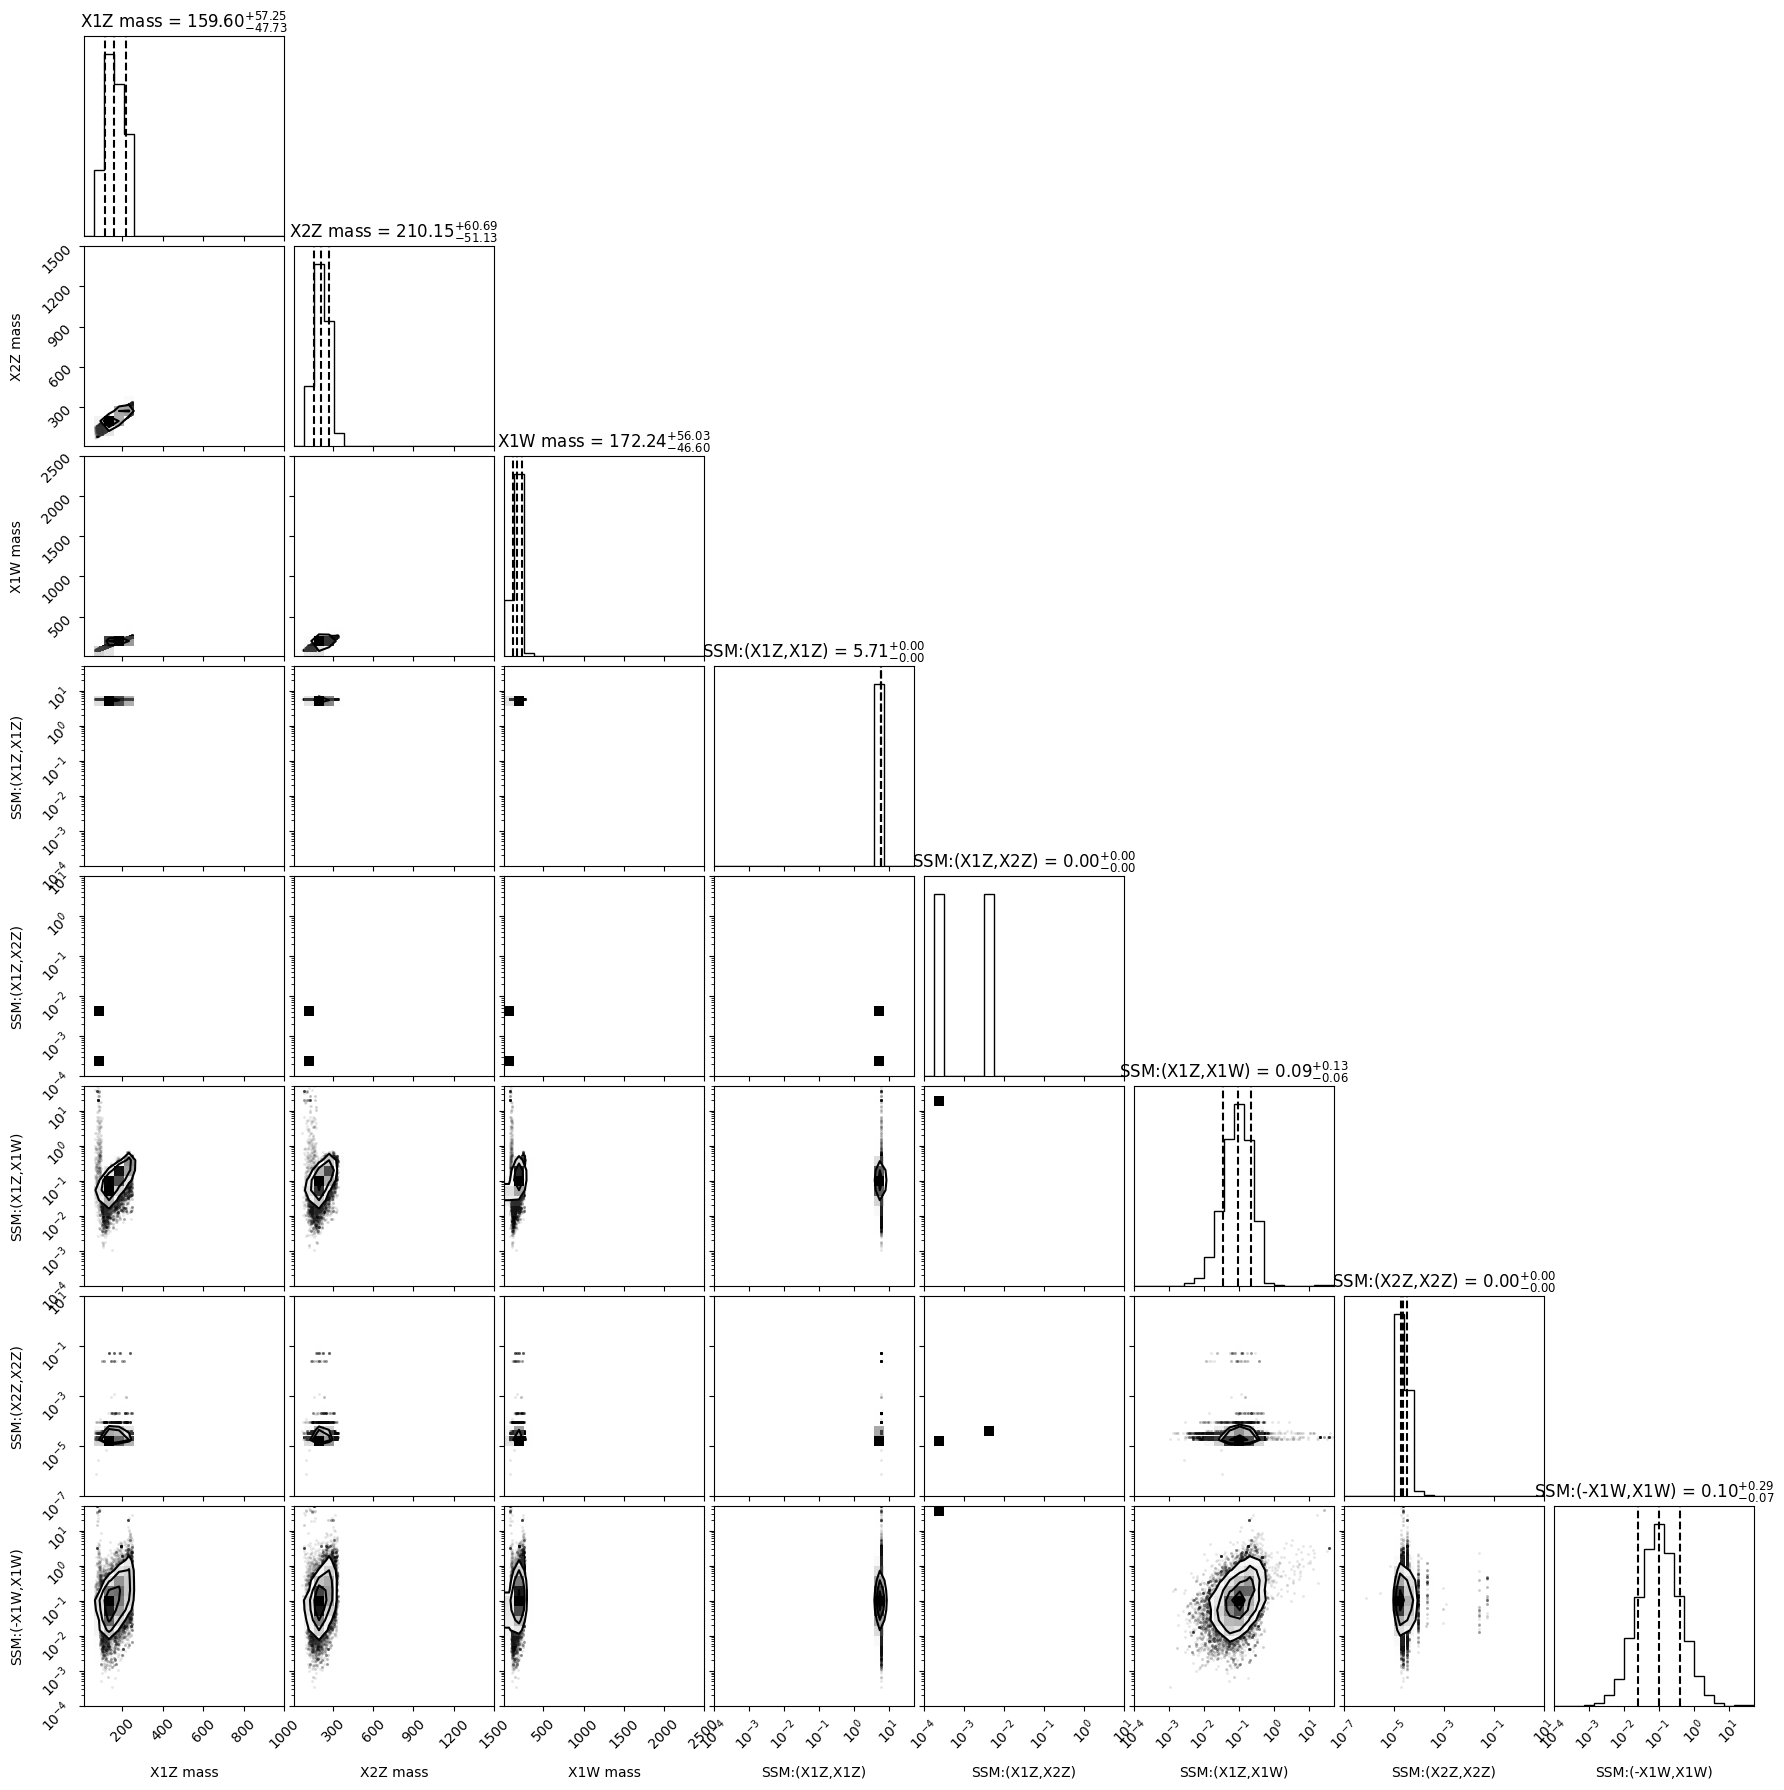

In [43]:
import corner
# Convert DataFrame to NumPy array
samples = data.values  # or data.to_numpy()

# Generate the corner plot
figure = corner.corner(samples, labels=data.columns, quantiles=[0.16, 0.5, 0.84], 
                        range=[(10,1000), (10,1500), (10,2500), (1e-04, 50), (1e-04, 1e01), (1e-04,50), (1e-07,10),(1e-04,50)], 
                        axes_scale = ["linear"]*3 +["log"]*5,  show_titles=True)

# Show the plot
import matplotlib.pyplot as plt
plt.show()

In [42]:
print(dataDict['SSM:(X2Z,X2Z)'])
print(max(dataDict['SSM:(X2Z,X2Z)']), min(dataDict['SSM:(X2Z,X2Z)']))

[0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.05244467535636759, 0.025070331523010088, 0.025070331523010088, 0.025070331523010088, 0.025070331523010088, 0.025070331523010088, 0.025070331523010088, 0.025070331523010088, 0.025